# Modelo Autorregresivo Integrado de Media Móvil (ARIMA)

Un modelo tipo ARIMA es un modelo estadístico que se presta para analizar series de tiempo. El objetivo de este tipo de modelo es predecir los movimientos futuros de valores examinando las **diferencias entre los valores de la serie de tiempo** en lugar de hacerlo a través de los **valores en sí**.



Así pues, los modelos ARIMA están formados por tres componentes:

-**Modelo Autorregresivo (AR)**: modelo en el que el valor de la variable de salida depende de sus valores anteriores. El parametro a cual se asocia este modelo se denomina como **p**,indica el número de observaciones de retraso en el modelo. También se conoce como orden de retraso.

$$
 \hat{y_{t}} = \omega_0+\varepsilon_{t}+\sum_{i=1}^p \alpha_i y_{t-i} 
$$

-**Modelo Integrado (I)**: representa la diferencia entre las observaciones para permitir que la serie temporal se vuelva estacionaria, es decir, los valores de los datos se reemplazan por la diferencia entre los valores de los datos y los valores anteriores.El parametro a cual se asocia este modelo se denomina como **d**, se trata del número de datos anteriores que se resta a cada valor. También se conoce como grado de diferenciación.

$$
\hat{y_{t}}= \mathcal{D}^d(y_t); \hspace{5mm} \mathcal{D}(y_t) = y_t-y_{t-1}
$$

-**Modelo de Media Móvil (MA)**: incorpora la dependencia entre una observación y un error residual de un modelo de media móvil aplicado a observaciones pasadas. El parametro a cual se asocia este modelo se denomina como **q**, es el tamaño de datos que se utiliza para la media móvil. También se conoce como orden de la media móvil

$$
\hat{y_{t}} = \omega_0+\varepsilon_{t}+\sum_{i=1}^q \beta_i \varepsilon_{t-i}
$$

Entonces, en conjunto tendríamos :

$$
\hat{y_{t}} = \omega_0+\varepsilon_{t}+\sum_{i=1}^p \alpha_i \mathcal{D}^d(y_{t-i})+\sum_{i=1}^q \beta_i \varepsilon_{t-i}
$$

## Ventajas de un modelo ARIMA:

- Útil para hacer pronósticos a corto plazo.
- Solo necesitan el histórico de datos para construirse.
- Permite modelar conjuntos de datos no estacionarios.

## Desventajas de un modelo ARIMA:

- No es un buen modelo para hacer pronósticos a largo plazo.
- Los modelos ARIMA difícilmente son capaces de predecir grandes cambios de tendencia (puntos de inflexión).
- Los parámetros del modelo ARIMA son subjetivos

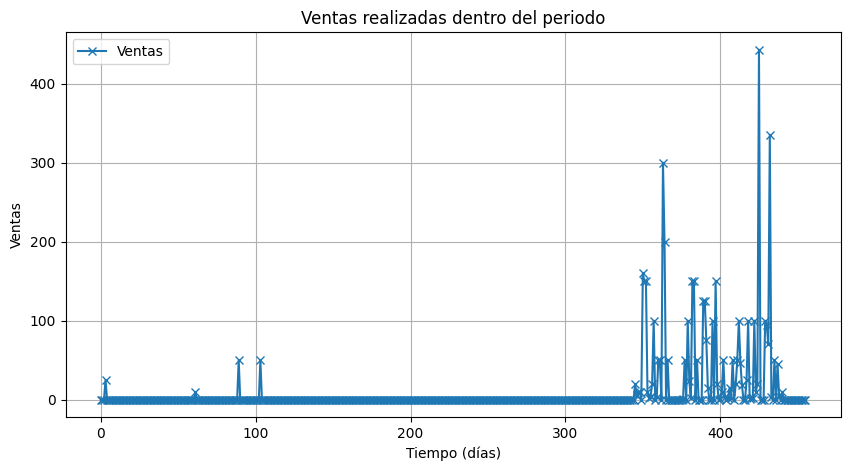

In [1]:
import pandas as pd
import os
from mlops.utils import data_dir,plot_series,make_time_series,time_period,Date,plt


os.chdir('..')

file_path = data_dir /'processed'/'HERMOSILLO, SON'/'MEMSTY050.parquet'
data = pd.read_parquet(file_path)
period = time_period(start_date=Date(2025,1,1),end_date=Date(2026,3,5))
_,time_series = make_time_series(data,period)

fig = plot_series(time_series)

plt.show(fig)

# Orden de retraso (p)

Una manera de estimar el orden de retraso es fijandonos en las gráficas de **autocorrelación parcial**

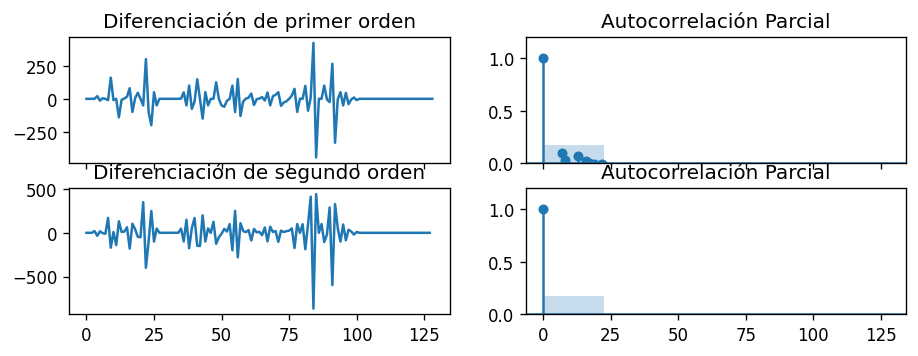

In [60]:
import numpy as np
from statsmodels.graphics.tsaplots import plot_pacf

def differentiation(time_series:np.ndarray,d:int)->np.ndarray|None:
    """
    Aplica 'd' grados de diferenciación a la serie de tiempo introducida

    Parametros:
    - time_series:numpy.ndarray, Serie de tiempo en cuestión
    - d: int, Grado de diferenciación

    Regresa: 
    - result_series:numpy.ndarray, Serie de tiempo diferenciada
    """

    result_series = time_series.copy()
    for i in range(1,d+1):
        if result_series.size==0:
            print("Serie vacía: No se puede realizar diferenciación en serie vacía")
            return None
        elif result_series.size==1:
            print(f"Serie incompleta: No se puede realizar diferenciación en serie de tamaño 1.\nGrados aplicados:{i-1}")
            return result_series

        result_series = np.diff(result_series)
    return result_series

clean_time_series = time_series[340:]

original = clean_time_series
first_diff = differentiation(clean_time_series,1)
second_diff = differentiation(clean_time_series,2)

plt.rcParams.update({'figure.figsize':(9,3), 'figure.dpi':120})

fig, axes = plt.subplots(2, 2, sharex=True)

# Primera diferenciación
axes[0, 0].plot(first_diff); axes[0, 0].set_title('Diferenciación de primer orden')
plot_pacf(first_diff, ax=axes[0, 1],title="Autocorrelación Parcial")
axes[0, 1].set(ylim=(0,1.2))
# Segunda diferenciación
axes[1, 0].plot(second_diff); axes[1, 0].set_title('Diferenciación de segundo orden')
plot_pacf(second_diff, ax=axes[1, 1],title="Autocorrelación Parcial")
axes[1, 1].set(ylim=(0,1.2))
plt.show()

# Grado de diferenciación (d)

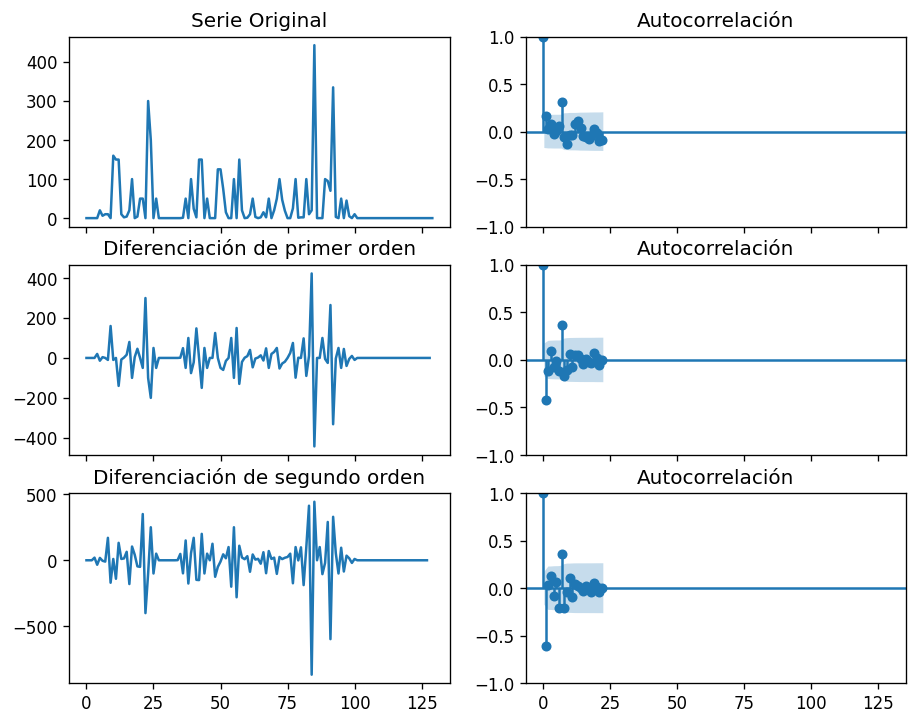

In [50]:
from statsmodels.graphics.tsaplots import plot_acf
plt.rcParams.update({'figure.figsize':(9,7), 'figure.dpi':120})

clean_time_series = time_series[340:]

original = clean_time_series
first_diff = differentiation(clean_time_series,1)
second_diff = differentiation(clean_time_series,2)

# Serie original
fig, axes = plt.subplots(3, 2, sharex=True)
axes[0, 0].plot(original); axes[0, 0].set_title('Serie Original')
plot_acf(original, ax=axes[0, 1],title="Autocorrelación")

# Primera diferenciación

axes[1, 0].plot(first_diff); axes[1, 0].set_title('Diferenciación de primer orden')
plot_acf(first_diff, ax=axes[1, 1],title="Autocorrelación")

# Segunda diferenciación
axes[2, 0].plot(second_diff); axes[2, 0].set_title('Diferenciación de segundo orden')
plot_acf(second_diff, ax=axes[2, 1],title="Autocorrelación")

plt.show()



# Orden de media móvil (q)

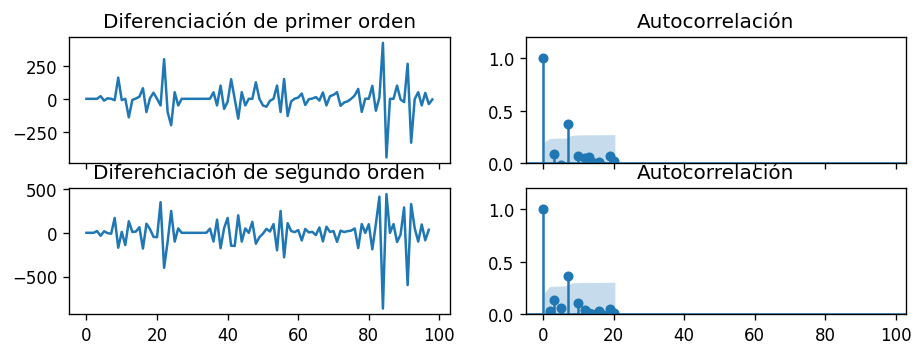

In [70]:
clean_time_series = time_series[340:440]

original = clean_time_series
first_diff = differentiation(clean_time_series,1)
second_diff = differentiation(clean_time_series,2)

plt.rcParams.update({'figure.figsize':(9,3), 'figure.dpi':120})

fig, axes = plt.subplots(2, 2, sharex=True)

# Primera diferenciación
axes[0, 0].plot(first_diff); axes[0, 0].set_title('Diferenciación de primer orden')
plot_acf(first_diff, ax=axes[0, 1],title="Autocorrelación")
axes[0,1].set(ylim=(0,1.2))

# Segunda diferenciación
axes[1, 0].plot(second_diff); axes[1, 0].set_title('Diferenciación de segundo orden')
plot_acf(second_diff, ax=axes[1, 1],title="Autocorrelación")
axes[1, 1].set(ylim=(0,1.2))
plt.show()

# Entrenamiento

c:\Users\federico.cirett\Documents\ct_dashboard\mlops\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\federico.cirett\Documents\ct_dashboard\mlops\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


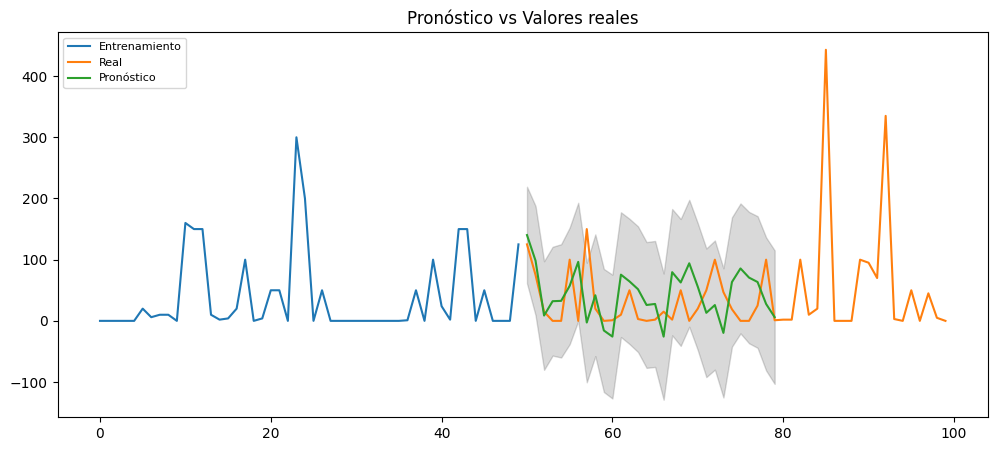

In [85]:
from statsmodels.tsa.arima.model import ARIMA

# Datos de entrenamiento
split_index=50
clean_time_series = pd.Series(time_series[340:440])
y_train = clean_time_series[:split_index]
y_test = clean_time_series[split_index:]

# Modelo
model = ARIMA(y_train,
              order=(24, 1, 5), # p,d,q
              enforce_stationarity=True,
              enforce_invertibility=True)  
fitted = model.fit(method_kwargs={"maxiter": 1000})  

# Forecast
forecast = fitted.get_forecast(steps=30)
fc = forecast.predicted_mean
conf = forecast.conf_int()

# Convertir a series de pandas
fc_series = pd.Series(fc, index=y_test.index)
lower_series = conf.iloc[:, 0]
upper_series = conf.iloc[:, 1]

# Plot
plt.figure(figsize=(12,5), dpi=100)
plt.plot(y_train, label='Entrenamiento')
plt.plot(y_test, label='Real')
plt.plot(fc_series, label='Pronóstico')
plt.fill_between(lower_series.index, lower_series, upper_series, 
                 color='k', alpha=.15)
plt.title('Pronóstico vs Valores reales')
plt.legend(loc='upper left', fontsize=8)
plt.show()


c:\Users\federico.cirett\Documents\ct_dashboard\mlops\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\federico.cirett\Documents\ct_dashboard\mlops\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


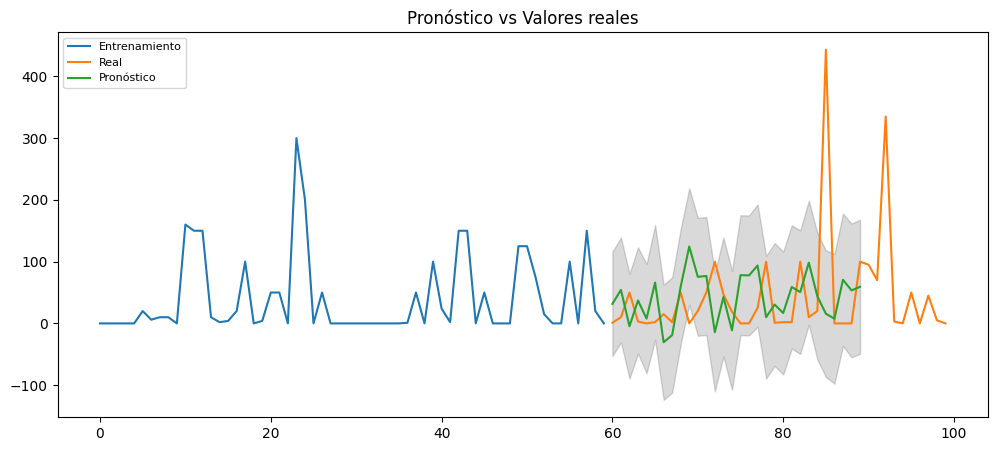

In [6]:
from statsmodels.tsa.arima.model import ARIMA

# Datos de entrenamiento
split_index=60
clean_time_series = pd.Series(time_series[340:440])
y_train = clean_time_series[:split_index]
y_test = clean_time_series[split_index:]

# Modelo
model = ARIMA(y_train,
              order=(24, 1, 5), # p,d,q
              enforce_stationarity=True,
              enforce_invertibility=True)  
fitted = model.fit(method_kwargs={"maxiter": 1000})  

# Forecast
forecast = fitted.get_forecast(steps=30)
fc = forecast.predicted_mean
conf = forecast.conf_int()

# Convertir a series de pandas
fc_series = pd.Series(fc, index=y_test.index)
lower_series = conf.iloc[:, 0]
upper_series = conf.iloc[:, 1]

# Plot
plt.figure(figsize=(12,5), dpi=100)
plt.plot(y_train, label='Entrenamiento')
plt.plot(y_test, label='Real')
plt.plot(fc_series, label='Pronóstico')
plt.fill_between(lower_series.index, lower_series, upper_series, 
                 color='k', alpha=.15)
plt.title('Pronóstico vs Valores reales')
plt.legend(loc='upper left', fontsize=8)
plt.show()


# Referencias

[Modelo ARIMA](https://www.probabilidadyestadistica.net/modelo-arima/)

[ARIMA tutorial](https://www.datacamp.com/tutorial/arima)

[ARIMA Model – Complete Guide to Time Series Forecasting in Python](https://machinelearningplus.com/time-series/arima-model-time-series-forecasting-python/)